# Report on changes to the temperature calculations

## Introduction

The purpose of this notebook is to describe some issues found with the way temperatures were dealt with in the AtLAST Sensitivity Calculator and how we are correcting for them. This notebook will work through the following steps:
1. Demonstrate the calculation of system temperature in version 1 of the code.
1. Demonstrate the issues with how the cosmic microwave background (CMB) was being dealt with and how to fix these.
1. Describe why we need to be using the Rayleigh-Jeans brightness temperature output from the am code rather than the thermodynamic brightness temperature output.
1. Show the changes needed to ensure all of our temperatures contributing to the noise are Rayleigh-Jeans brightness temperatures.

We begin by importing relevant modules and defining the location of the files output from the [am code](https://zenodo.org/records/13748403).

In [1]:
# Import necessary modules
import numpy as np
import matplotlib.pyplot as pl
from astropy import units as u
import astropy.constants as const

# Directory for the location of the am output
amfilesdir = 'am_files/'

# Hide divide by 0 warnings
import warnings
warnings.filterwarnings("ignore")

## Sensitivity calculator version 1

In version 1 of the calculator, the system temperature was defined as

$$    T_{sys} = \frac{1}{\eta_{eff} \mathfrak{t}} \times [T_{rx} + (\eta_{eff} T_{sky}) + (1-\eta_{eff}) T_{amb}]$$

where 
* $\eta_{eff}$ is the forward efficiency of the telescope
* $\mathfrak{t}$ is the atmospheric transmittance
* $T_{rx}$ is the receiver temperature
* $T_{sky}$ is the sky temperature
* $T_{amb}$ is the ambient temperature

The receiver temperature was calculated as

$$ T_{rx} = \frac{5h\nu}{k} $$

where
* $h$ is Planck's constant
* $\nu$ is the observing frequency
* $k$ is Boltzmann's constant

The sky temperature was calculated as

$$    T_{sky} = (1- \mathfrak{t}) T_{atm} + T_{cmb}$$

where
* $ T_{atm}$ is the atmospheric temperature
* $  T_{cmb}$ is the cosmic microwave background temperature

To calculate the atmospheric temperature we make use of the am code. We make use of the provided configuration file for ACT, which is close to the potential sites for AtLAST, and modify it to output just the thermodynamic (Planck) brightness temperature, $T_{b}$ (which was interpreted as $T_{sky}(z=0)$), and opacity, $\tau_0$ at zenith. 

Following [ALMA memo 602](https://library.nrao.edu/public/memos/alma/main/memo602.pdf), we calculated $T_{sky}$ at the desired zenith angle, $z$, (90 degrees minus the elevation) by setting 

$$ T_{atm} = \frac{T_{sky}(z=0)}{1-e^{-\tau_0}} $$
$$ \mathfrak{t} = e^{-\tau_0\sec{z}} $$
$$ T_{sky}(z) = T_{atm}(1-\mathfrak{t}) $$

In the following we assume for our example a 25% water column. The am output is then created at the command line using the command (this can already be found in the am_files directory and doesn't need to be recreated): 

`am ACT_annual_25_inc_Tcmb.amc 10 GHz 2000 GHz 10 MHz 90 deg 1.0 > ACT_10_2000_GHz_10MHz_el90_annual_25_inc_Tcmb.txt`


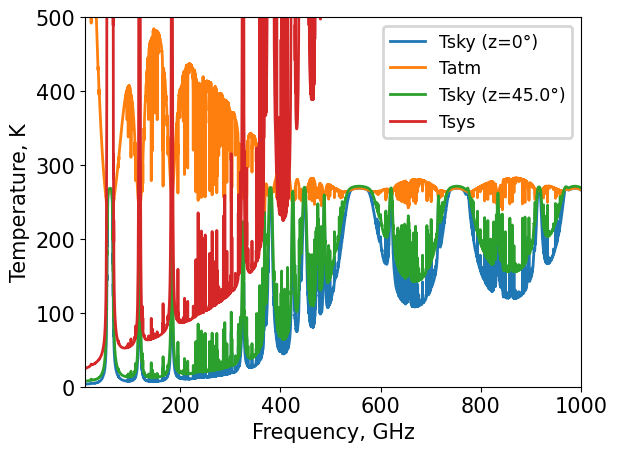

In [2]:
# file name for the output from the am code
filename = amfilesdir + 'ACT_10_2000_GHz_10MHz_el90_annual_25_inc_Tcmb.txt'

# Telescope and cosmological constants
eta_eff = 0.95  # forward efficiency
tamb = 270*u.K  # ambient temperature
tcmb = 2.726*u.K    # CMB temperature

# User parameter
elevation = 45*u.deg   # angle from the horizon of the direction in which the telescope is pointing 

# Read in file
fileimp=np.genfromtxt(filename)

freqs = fileimp[:,0]*u.GHz  # frequency range
tskyz0 = fileimp[:,2]*u.K  # T_sky at zenith from the am file output
tau0 = fileimp[:,1] # opacity at zenith

tatm = tskyz0/(1-np.exp(-tau0))     # atmospheric temperature (see equation above)
zenith = 90*u.deg-elevation         # convert from elevation angle to angle from zenith
tau = tau0/np.cos(zenith)   # optical depth at given elevation
transmittance = np.exp(-tau)    # transmittance at given elevation
tskyznon0 = tatm * (1-transmittance) + tcmb # Tsky at chosen elevation

trx = 5*const.h*freqs/const.k_B # receiver temperature

# System temperature combining the receiver temperature, sky temperature and ambient temperature multiplied by the appropriate efficiencies
tsys_1 = ((1/(eta_eff*transmittance))*(trx + (eta_eff*tskyznon0) + (1-eta_eff)*tamb)).to('K')

# Plot of these temperatures
pl.figure()
pl.plot(freqs, tskyz0,label='Tsky (z=0°)')
pl.plot(freqs, tatm, label='Tatm')  
pl.plot(freqs, tskyznon0,label='Tsky (z='+str(zenith.value)+'°)')   
pl.plot(freqs, tsys_1, label='Tsys')
#pl.xscale('log')
pl.xlim(10,1000)
pl.ylim(0, 500)
pl.xlabel('Frequency, GHz')
pl.ylabel('Temperature, K')
pl.legend(prop={'size':'small'},numpoints=1)




T_atm is described in the ALMA memo as the mean physical temperature, however it is clear from this that that's not the case given how high the temperature goes.

## Cosmic Microwave Background

The am configuration files contain a parameter `T0` that represents the temperature at the top of the atmosphere. In the files we were using, that was set to 2.7K to represent the CMB. However, from the equation for $T_{sky}$ given above, we are clearly also adding $T_{cmb}$ and, therefore, we are double counting it. 

To avoid this, we change `T0` in the configuration files to be 0K. 

In addition, there is a slight error in the Tsky equation, in that there should be a factor of transmittance preceding the $T_{cmb}$ (see e.g. equation 13.114 of Interferometry and Synthesis in Radio Astronomy), i.e.

$$    T_{sky} = (1- \mathfrak{t}) T_{atm} + \mathfrak{t}\, T_{cmb}$$

The am output is then created using the command: 

`am ACT_annual_25.amc 10 GHz 2000 GHz 10 MHz 90 deg 1.0 > ACT_10_2000_GHz_10MHz_el90_annual_25.txt`

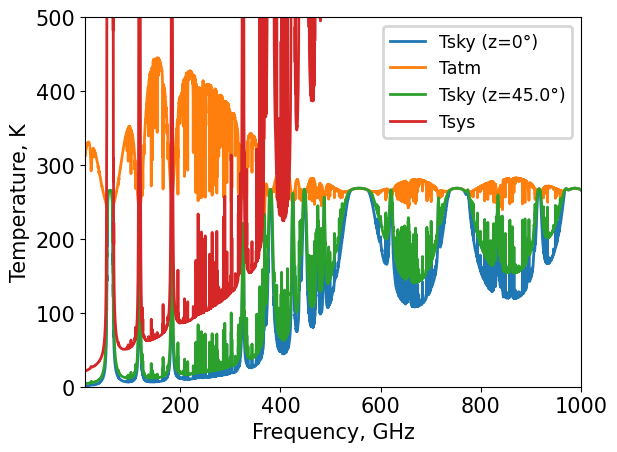

In [3]:
# file name for the output from the am code
filename = amfilesdir + 'ACT_10_2000_GHz_10MHz_el90_annual_25.txt'

# Read in file
fileimp=np.genfromtxt(filename)

freqs = fileimp[:,0]*u.GHz  # frequency range
tskyz0 = fileimp[:,2]*u.K  # T_sky at zenith from the am file output
tau0 = fileimp[:,1] # opacity at zenith

tatm = tskyz0/(1-np.exp(-tau0))     # atmospheric temperature (see equation above)
zenith = 90*u.deg-elevation         # convert from elevation angle to angle from zenith
tau = tau0/np.cos(zenith)   # optical depth at given elevation
transmittance = np.exp(-tau)    # transmittance at given elevation
tskyznon0 = tatm * (1-transmittance) + transmittance * tcmb # Tsky at chosen elevation

# System temperature combining the receiver temperature, sky temperature and ambient temperature multiplied by the appropriate efficiencies
tsys_2 = ((1/(eta_eff*transmittance))*(trx + (eta_eff*tskyznon0) + (1-eta_eff)*tamb)).to('K')

# Plot of these temperatures
pl.figure()
pl.plot(freqs, tskyz0,label='Tsky (z=0°)')
pl.plot(freqs, tatm, label='Tatm')
pl.plot(freqs, tskyznon0,label='Tsky (z='+str(zenith.value)+'°)')
pl.plot(freqs, tsys_2, label='Tsys')
#pl.xscale('log')
pl.xlim(10,1000)
pl.ylim(0, 500)
pl.xlabel('Frequency, GHz')
pl.ylabel('Temperature, K')
pl.legend(prop={'size':'small'},numpoints=1)


This has clearly reduced the issue with Tatm at low frequencies (<~100GHz), as can also be seen in the following plot that shows the fractional change in Tsys, although it doesn't solve the problem entirely.

(0.8, 1.0)

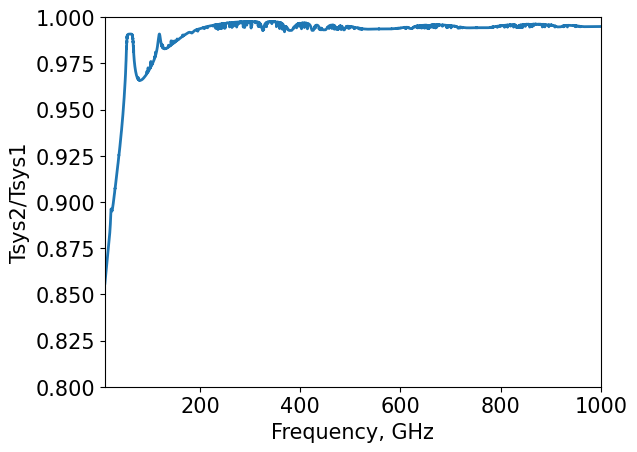

In [4]:
pl.figure()
pl.plot(freqs, tsys_2/tsys_1)
pl.xlabel('Frequency, GHz')
pl.ylabel('Tsys2/Tsys1')
#pl.xscale('log')
pl.xlim(10,1000)
pl.ylim(0.8, 1)

## Rayleigh-Jeans brightness temperature output from am

As noted earlier, we are using the thermodynamic brightness temperature output from the am code. The am code can also produce the Rayleigh-Jeans brightness temperature, $T_{rj}$. The am manual discusses the difference between the two in section 1.2.4. In particular, it notes that "$kT_{rj} (ν)$ is the power per unit bandwidth at frequency ν incident on a detector
coupled to a single-mode transmission line terminated by a matched load at physical temperature $T_b (ν)$". This and section 5.3.2 show that it is $T_{rj}$ that we want to use for calculating a system temperature, rather than the $T_b$ that we have been using, which is the thermodynamic brightness temperature.

We have therefore edited the configuration files to output $T_{rj}$ (shown as $T_{sky}(z=0°)$ in the following plots) rather than $T_{b}$ (shown as $T_{sky}(z=0°)$ in the preceding plots). The am output is then created using the command: 

`am ACT_annual_25_trj.amc 10 GHz 2000 GHz 10 MHz 90 deg 1.0 > ACT_10_2000_GHz_10MHz_el90_annual_25_trj.txt`

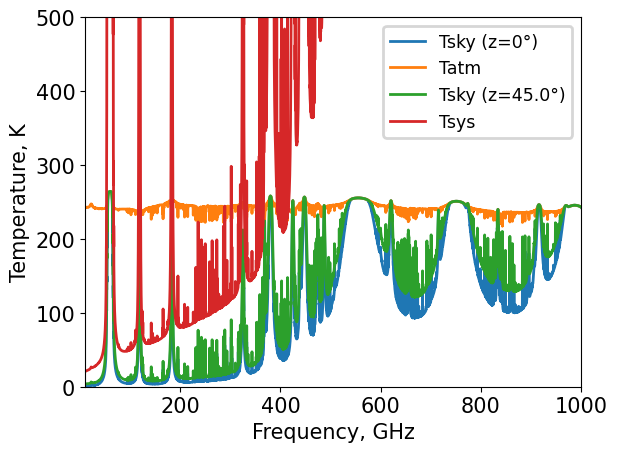

In [5]:
# file name for the output from the am code
filename = amfilesdir + 'ACT_10_2000_GHz_10MHz_el90_annual_25_trj.txt'

# Read in file
fileimp=np.genfromtxt(filename)

freqs = fileimp[:,0]*u.GHz  # frequency range
tskyz0 = fileimp[:,2]*u.K  # T_sky at zenith from the am file output
tau0 = fileimp[:,1] # opacity at zenith

tatm = tskyz0/(1-np.exp(-tau0))     # atmospheric temperature (see equation above)
zenith = 90*u.deg-elevation         # convert from elevation angle to angle from zenith
tau = tau0/np.cos(zenith)   # optical depth at given elevation
transmittance = np.exp(-tau)    # transmittance at given elevation
tskyznon0 = tatm * (1-transmittance) + transmittance * tcmb # Tsky at chosen elevation

# System temperature combining the receiver temperature, sky temperature and ambient temperature multiplied by the appropriate efficiencies
tsys_3 = ((1/(eta_eff*transmittance))*(trx + (eta_eff*tskyznon0) + (1-eta_eff)*tamb)).to('K')

# Plot of these temperatures
pl.figure()
pl.plot(freqs, tskyz0,label='Tsky (z=0°)')
pl.plot(freqs, tatm, label='Tatm')
pl.plot(freqs, tskyznon0,label='Tsky (z='+str(zenith.value)+'°)')
pl.plot(freqs, tsys_3, label='Tsys')
#pl.xscale('log')
pl.xlim(10,1000)
pl.ylim(0, 500)
pl.xlabel('Frequency, GHz')
pl.ylabel('Temperature, K')
pl.legend(prop={'size':'small'},numpoints=1)


From the above plot, we see now that the atmospheric temperature is now realistic. It's not constant because our atmosphere model is multi-layered and different scale heights are probed at different frequencies. It's not obvious from this plot, but it does also decline with increasing frequency as it is a Rayleigh-Jeans brightness temperature here and not a physical temperature. 

The following plot shows how the system temperature now compares to that from version 1 of the code. We can see that this change leads to a few percent reduction in the final system temperature across all frequencies.

(0.8, 1.0)

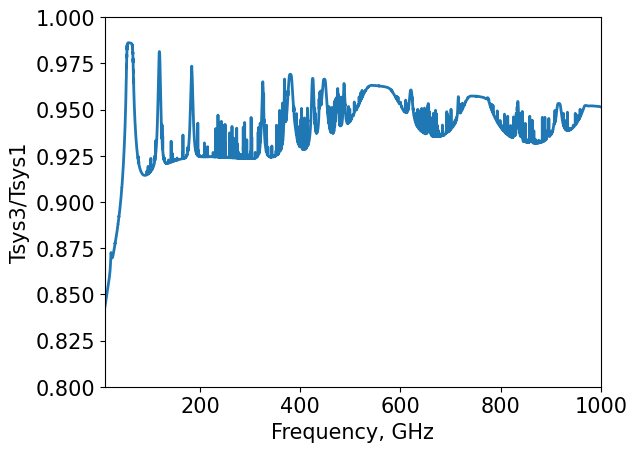

In [6]:
pl.figure()
pl.plot(freqs, tsys_3/tsys_1)
pl.xlabel('Frequency, GHz')
pl.ylabel('Tsys3/Tsys1')
#pl.xscale('log')
pl.xlim(10,1000)
pl.ylim(0.8, 1)

## Ensuring all temperatures are Rayleigh-Jeans brightness temperatures

It's not only the sky temperature that needs to be a Rayleigh-Jeans brightness temperature in these equations, but this is also true of all of the contributions to the noise (see for instance section 13.2.1 of Interferometry and Synthesis in Radio Astronomy), i.e. both the CMB and ambient temperatures need to be converted to Rayleigh-Jeans brightness temperatures. The receiver temperature does not need to be converted as it is already defined in terms of a Rayleigh-Jeans brightness temperature. This also ensures consistency between the heterodyne instruments and the MKID instruments, where this function is already applied.

We now define a noise temperature function to facilitate this conversion. This implements equation 10 from ALMA memo 602:
$$ T_n = T \frac{hν/kT}{e^{hν/kT} − 1} $$

In [7]:
def noise_temperature(temperature, frequency):
    """
    Function to convert a thermodynamic temperature to a Rayleigh-Jeans brightness temperature.
    See e.g. equation 7.5 from Interferometry and Synthesis in Radio Astronomy.
    Temperature and frequency will need to have astropy units. 
    """
    ratio = (const.h*frequency)/(const.k_B*temperature)
    noise_temp = temperature*(ratio/np.expm1(ratio))
    return noise_temp

We then apply this to our $T_{cmb}$ and $T_{amb}$ and so now we have the following equations for the sky temperature and system temperature:

$$ T_{sky} = (1- \mathfrak{t}) T_{atm} + \mathfrak{t}\, \frac{hν/k}{e^{hν/kT_{cmb}} − 1} $$
$$ T_{sys} = \frac{1}{\eta_{eff} \mathfrak{t}} \times [T_{rx} + (\eta_{eff} T_{sky}) + (1-\eta_{eff}) \frac{hν/k}{e^{hν/kT_{amb}} − 1}]$$


This is our final change that solves all of the issues previously noted. In the following we then show how this impacts our plot of the temperatures.

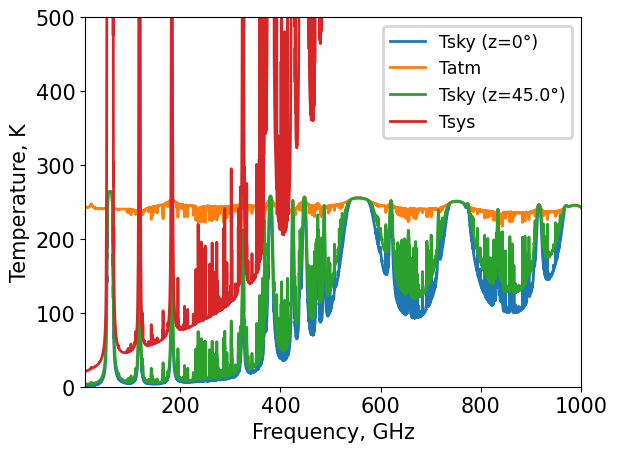

In [8]:
# Sky temperature at given elevation - now ensuring all temperatures are Rayleigh-Jeans brightness temperatures
tskyznon0 = tatm * (1-transmittance) + transmittance * noise_temperature(tcmb, freqs)

# System temperature combining the receiver temperature, sky temperature and ambient temperature multiplied by the appropriate efficiencies 
# Now ensuring that all temperatures are Rayleigh-Jeans brightness temperatures
tsys_4 = ((1/(eta_eff*transmittance))*(trx + (eta_eff*tskyznon0) + (1-eta_eff)*noise_temperature(tamb, freqs))).to('K')

# Plot of these temperatures
pl.figure()
pl.plot(freqs, tskyz0,label='Tsky (z=0°)')
pl.plot(freqs, tatm, label='Tatm')
pl.plot(freqs, tskyznon0,label='Tsky (z='+str(zenith.value)+'°)')
pl.plot(freqs, tsys_4, label='Tsys')
#pl.xscale('log')
pl.xlim(10,1000)
pl.ylim(0, 500)
pl.xlabel('Frequency, GHz')
pl.ylabel('Temperature, K')
pl.legend(prop={'size':'small'},numpoints=1)

From the following plot that compares our final system temperature with that from version 1 of the code, we see that this final change is small compared to the previous step and mostly in the range 100-400 GHz. This is due to the change in Tcmb, which is most important at the lower frequencies.

(0.8, 1.0)

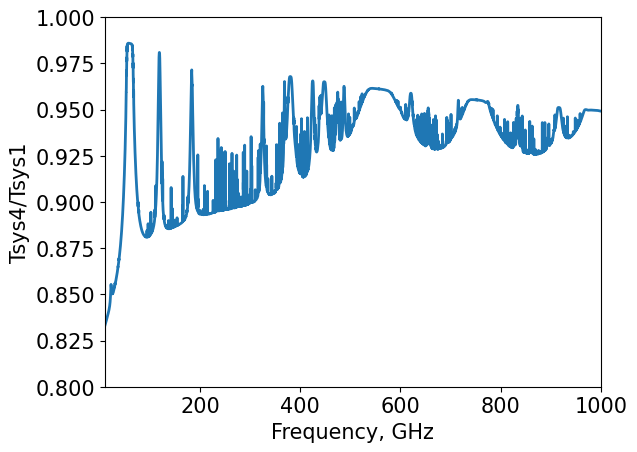

In [9]:
pl.figure()
pl.plot(freqs, tsys_4/tsys_1)
pl.xlabel('Frequency, GHz')
pl.ylabel('Tsys4/Tsys1')
#pl.xscale('log')
pl.xlim(10,1000)
pl.ylim(0.8, 1)

Text(0.5, 1.0, 'Ratio of Final to Original Tsys')

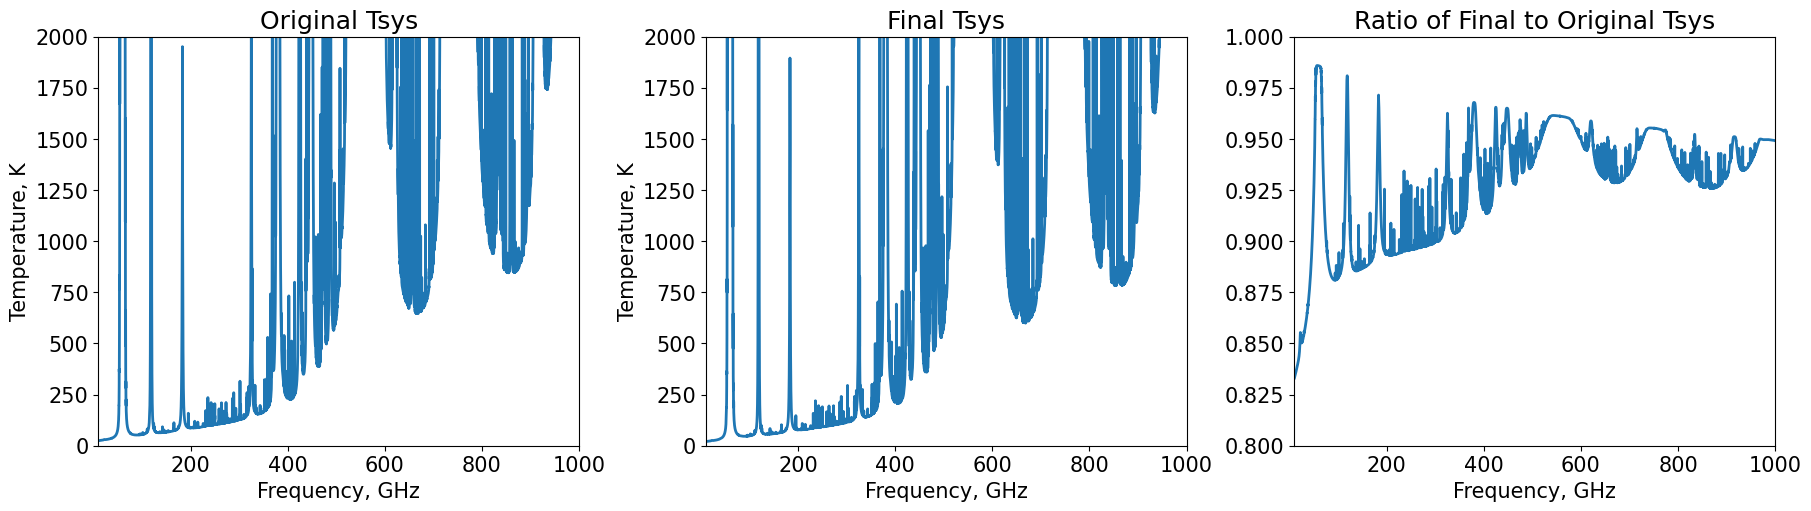

In [11]:
fig, (ax1,ax2,ax3) = pl.subplots(1,3, figsize=(18,5), layout='constrained')

# Original Tsys
ax1.plot(freqs, tsys_1, label='Tsys1')
ax1.set_xlim(10,1000)
ax1.set_ylim(0, 2000)
ax1.set_xlabel('Frequency, GHz')
ax1.set_ylabel('Temperature, K')
ax1.set_title('Original Tsys')

# Changed Tsys
ax2.plot(freqs, tsys_4, label='Tsys4')
ax2.set_xlim(10,1000)
ax2.set_ylim(0, 2000)
ax2.set_xlabel('Frequency, GHz')
ax2.set_ylabel('Temperature, K')
ax2.set_title('Final Tsys')

# Ratio between the system temperatures
ax3.plot(freqs, tsys_4/tsys_1)
ax3.set_xlabel('Frequency, GHz')
ax3.set_xlim(10,1000)
ax3.set_ylim(0.8, 1)
ax3.set_title('Ratio of Final to Original Tsys')


From these we can calculate the change expected to our functional tests. The functional tests calculate the sensitivity and observing time based on the default parameters. The sensitivity should change by the ratio of the final to original system temperature and the the observing time should change by the square of this ratio. Currently, the default frequency is 100 GHz. We can interpolate to find what the ratio is at this frequency.

In [15]:
nu = 100*u.GHz # Default frequency in GHz used by the functional tests
print('Ratio of final to original system temperature at 100 GHz:', np.interp(nu, freqs, tsys_4/tsys_1))

Ratio of final to original system temperature at 100 GHz: 0.8819414998602607


## Summary

This notebook explains 
* how the temperatures were handled in version 1 of the calculator
* why we need to change the configuration files to set T0=0K and have them output $T_{rj}$
* why we need to update our $T_{sky}$ equation to include a factor of transmittance
* why we need to update our $T_{sys}$ and $T_{sky}$ equations to use Rayleigh-Jeans brightness temperature consistently
* the impact these changes have on the final system temperature and the sensitivity/observing time.